# Домашнее задание 3. Анализ данных

Задание выполнил(а):

    (Корх Никита)

# Часть I

Каждое задание в этой части оценивается в 0,15 баллов. Всего за выполнение этой части можно получить 2,55 балла.

In [24]:
import pandas as pd
import seaborn as sns
from scipy.stats import norm

In [25]:
DIABETS = 'https://raw.githubusercontent.com/evgpat/datasets/main/pima_indians_diabetes.csv'
BABIES = 'https://raw.githubusercontent.com/evgpat/datasets/main/babies_all.txt'

Будем работать с датасетом Pima Indian Diabetes - это набор данных из Национального института диабета, болезней органов пищеварения и почек. Целью набора данных является диагностическое прогнозирование наличия диабета у пациента. Несколько ограничений были наложены на выбор этих экземпляров из большой базы данных. В частности, все пациенты здесь - женщины в возрасте от 21 года, индийского происхождения.

In [32]:
data = pd.read_csv(DIABETS)
data.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
5,5,116.0,74.0,NaN,NaN,25.6,0.201,30,0
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
7,10,115.0,NaN,NaN,NaN,35.3,0.134,29,0
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
9,8,125.0,96.0,NaN,NaN,NaN,0.232,54,1


Описание данных:

- __Pregnancies__ - данная единица отображает количество беременностей, единицы измерения - целые числа от 0 до N. Тип переменной - количественная, дискретная.
- __Glucose__ - данная единица отображает уровень глюкозы в крови, единицы измерения - целые числа. Тип переменной - количественная, дискретная.
- __BloodPressure__ - данная единица отображает артериальное давление, единицы измерения - миллиметры р/с, целые числа. Тип переменной - количественная, дискретная.
- __SkinThickness__ - данная единица отображает обхват трицепса в миллиметрах, целые числа. Тип переменной - количественная, дискретная.
- __Insulin__ - данная единица отображает уровень инсулина в крови, целые числа. Тип переменной - количественная, дискретная.
- __BMI__ - данная единица отображает индекс массы тела. Тип переменной - количественная, непрерывная.
- __DiabetesPedigreeFunction__ - данная единица отображает риск наследственного диабета в зависимости наличия диабета у родственников. Выражается десятичной дробью от 0 до 1. Тип переменной - количественная, непрерывная.
- __Age__ - данная единица отражает возраст в целых числах. Тип переменной - количественная, дискретная.
- __Class__ - данная единица отражает наличие диабета у субъекта, выражена 0(здоров) или 1(болен). Тип переменной - категориальная, бинарная.

## Задание 1

Как вы видите, в данных много пропусков (NaN). Любым способом посчитайте количество пропусков в каждом из столбцов.

Для тех переменных, в которых есть пропуски, выведите количество пропущенных значений в следующем формате:

**"В переменной {название переменной} {количество} пропущенных значений"**

In [33]:
missing_values = data.isnull().sum()

for column in data.columns:
    if missing_values[column] > 0:
        print(f"В переменной {column} {missing_values[column]} пропущенных значений")

В переменной Glucose 5 пропущенных значений
В переменной BloodPressure 35 пропущенных значений
В переменной SkinThickness 227 пропущенных значений
В переменной Insulin 374 пропущенных значений
В переменной BMI 11 пропущенных значений


## Задание 2

Замените все пропуски дискретных признаков соответствующими медианами, непрерывных признаков - средними значениями.

In [41]:
data_clean = data.copy()

for col in ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'Age']:
    median_val = data_clean[col].median()
    data_clean[col].fillna(median_val, inplace=True)

for col in ['BMI', 'DiabetesPedigreeFunction']:
    mean_val = data_clean[col].mean()
    data_clean[col].fillna(mean_val, inplace=True)


C:\Users\vitao\AppData\Local\Temp\ipykernel_15200\1165641486.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_clean[col].fillna(median_val, inplace=True)
C:\Users\vitao\AppData\Local\Temp\ipykernel_15200\1165641486.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

## Задание 3

Выведите основные статистики (минимум, максимум, среднее, дисперсию, квантили) для всех столбцов.

In [42]:
basic_stats = data_clean.describe()
basic_stats

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Class
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875151,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.400000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Задание 4

У скольких женщин строго старше 50 лет обнаружен диабет?

In [43]:
women_over_50_diabetes = data_clean[(data_clean['Age'] > 50) & (data_clean['Class'] == 1)]
count_women = len(women_over_50_diabetes)  
print(f"У {count_women} женщин старше 50 лет обнаружен диабет")

У 38 женщин старше 50 лет обнаружен диабет


## Задание 5

Найдите трех женщин с наибольшими числом беременностей.

In [44]:
top_pregnancies = data_clean.nlargest(3, 'Pregnancies')  
top_pregnancies[['Pregnancies', 'Age', 'Class']]  


,Pregnancies,Age,Class
159,17,47,1
88,15,43,1
298,14,46,1


## Задание 6

Сколько женщин возраста между 30 и 40 успело родить 3 или более детей?

In [45]:
women_30_40 = data_clean[(data_clean['Age'] >= 30) & (data_clean['Age'] <= 40)]
women_3_plus = women_30_40[women_30_40['Pregnancies'] >= 3]
count_women = len(women_3_plus)  
print(f"Сколько женщин возраста 30-40 лет родили 3+ детей: {count_women}")

Сколько женщин возраста 30-40 лет родили 3+ детей: 142


## Задание 7

Нормальным кровяным давлением будем считать давление в диапазоне [80-89]. У какого процента женщин давление нормальное?

In [19]:
normal_bp = data_clean[(data_clean['BloodPressure'] >= 80) & (data_clean['BloodPressure'] <= 89)]
total_women = len(data_clean)  
normal_bp_count = len(normal_bp)  
percentage = (normal_bp_count / total_women) * 100  
print(f"Процент женщин с нормальным давлением: {percentage:.2f}%")

Процент женщин с нормальным давлением: 18.88%


## Задание 8

Считается, что BMI >= 30 - это признак ожирения.
У скольких женщин с признаками ожирения кровяное давление выше среднего?

In [20]:
obese = data_clean[data_clean['BMI'] >= 30]
mean_bp = data_clean['BloodPressure'].mean()
obese_high_bp = obese[obese['BloodPressure'] > mean_bp]
count_obese_high_bp = len(obese_high_bp)  
print(f"Женщин с ожирением и давлением выше среднего: {count_obese_high_bp}")

Женщин с ожирением и давлением выше среднего: 251


## Задание 9

Сравните средние значения для признаков __Glucose,	BloodPressure,	Insulin__ среди тех, у кого обнаружен диабет, и тех, у кого его нет.

In [21]:
glucose_diabetes = data_clean[data_clean['Class'] == 1]['Glucose'].mean()  
glucose_no_diabetes = data_clean[data_clean['Class'] == 0]['Glucose'].mean()  
print(f"Средняя глюкоза у больных диабетом: {glucose_diabetes:.2f}")
print(f"Средняя глюкоза у здоровых: {glucose_no_diabetes:.2f}")

Средняя глюкоза у больных диабетом: 142.13
Средняя глюкоза у здоровых: 110.68


In [22]:
bp_diabetes = data_clean[data_clean['Class'] == 1]['BloodPressure'].mean()
bp_no_diabetes = data_clean[data_clean['Class'] == 0]['BloodPressure'].mean()
print(f"\nСреднее давление у больных диабетом: {bp_diabetes:.2f}")
print(f"Среднее давление у здоровых: {bp_no_diabetes:.2f}")


Среднее давление у больных диабетом: 75.12
Среднее давление у здоровых: 70.92


In [23]:
insulin_diabetes = data_clean[data_clean['Class'] == 1]['Insulin'].mean()
insulin_no_diabetes = data_clean[data_clean['Class'] == 0]['Insulin'].mean()
print(f"\nСредний инсулин у больных диабетом: {insulin_diabetes:.2f}")
print(f"Средний инсулин у здоровых: {insulin_no_diabetes:.2f}")


Средний инсулин у больных диабетом: 164.70
Средний инсулин у здоровых: 127.79


## Задание 10

Постройте гистограммы для любых двух количественных признаков.

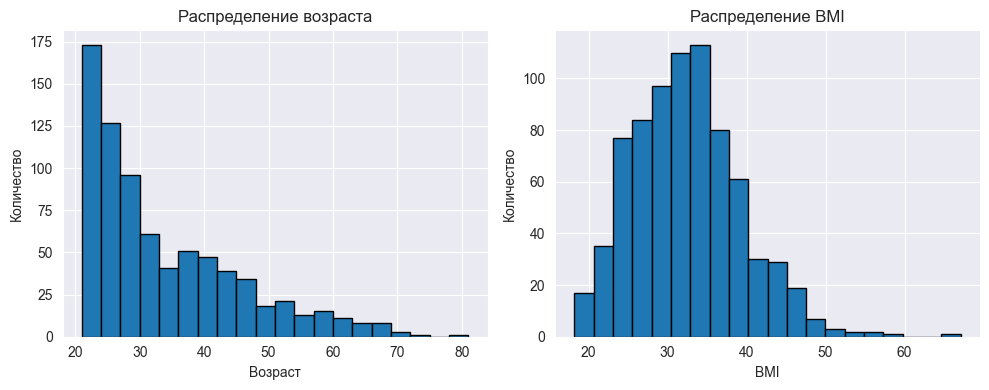

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)  
plt.hist(data_clean['Age'], bins=20, edgecolor='black')
plt.title('Распределение возраста')
plt.xlabel('Возраст')
plt.ylabel('Количество')

plt.subplot(1, 2, 2)  
plt.hist(data_clean['BMI'], bins=20, edgecolor='black')
plt.title('Распределение BMI')
plt.xlabel('BMI')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

## Задание 11

Постройте круговую диаграмму для признака __Class__.

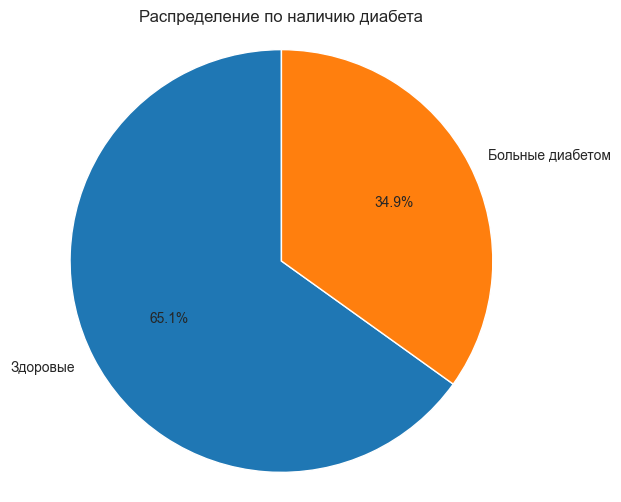

In [26]:
diabetes_counts = data_clean['Class'].value_counts()  

labels = ['Здоровые', 'Больные диабетом']
sizes = diabetes_counts.values

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Распределение по наличию диабета')
plt.axis('equal')  
plt.show()

## Задание 12

Постройте распределение для признака __BMI__ и сравните его с нормальным (напишите вывод в новой markdown-ячейке под графиками)

In [28]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

Постройте нормальное распределение поверх графика.

In [ ]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

## Задание 13

Постройте следующий график: процент больных диабетом в зависимости от числа беременностей.

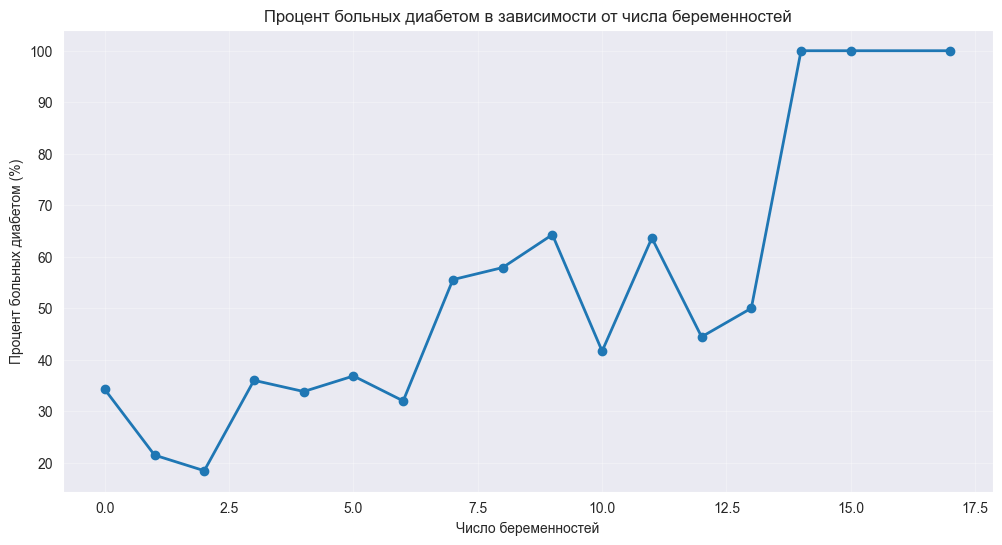

In [29]:
pregnancy_groups = data_clean.groupby('Pregnancies')['Class'].mean() * 100  

plt.figure(figsize=(12, 6))
plt.plot(pregnancy_groups.index, pregnancy_groups.values, marker='o', linewidth=2)
plt.title('Процент больных диабетом в зависимости от числа беременностей')
plt.xlabel('Число беременностей')
plt.ylabel('Процент больных диабетом (%)')
plt.grid(True, alpha=0.3)
plt.show()

## Задание 14

Добавьте новый бинарный признак:

__wasPregnant__ $\in$ {0,1} - была женщина беременна (1) или нет (0)

In [30]:
data_clean['wasPregnant'] = data_clean['Pregnancies'].apply(lambda x: 1 if x > 0 else 0)

print(data_clean[['Pregnancies', 'wasPregnant']].head(10))

   Pregnancies  wasPregnant
0            6            1
1            1            1
2            8            1
3            1            1
4            0            0
5            5            1
6            3            1
7           10            1
8            2            1
9            8            1


## Задание 15

Сравните процент больных диабетом среди женщин, которые были беременны и не были.

In [32]:
diabetes_rate_pregnant = data_clean[data_clean['wasPregnant'] == 1]['Class'].mean() * 100
diabetes_rate_not_pregnant = data_clean[data_clean['wasPregnant'] == 0]['Class'].mean() * 100

print(f"Процент больных диабетом среди тех, кто был беременной: {diabetes_rate_pregnant:.2f}%")
print(f"Процент больных диабетом среди тех, кто не был беременной: {diabetes_rate_not_pregnant:.2f}%")

Процент больных диабетом среди тех, кто был беременной: 35.01%
Процент больных диабетом среди тех, кто не был беременной: 34.23%


## Задание 16

Добавьте новый категориальный признак __bodyType__ на основе столбца BMI:

__BMI Categories:__
    
Underweight = <18.5

Normal weight = 18.5–24.9

Overweight = 25–29.9

Obesity = BMI of 30 or greater

Признак должен принимать значения Underweight, Normal weight, Overweight и Obesity.

In [33]:
def get_body_type(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25:
        return 'Normal weight'
    elif 25 <= bmi < 30:
        return 'Overweight'
    else:
        return 'Obesity'

data_clean['bodyType'] = data_clean['BMI'].apply(get_body_type)

print(data_clean[['BMI', 'bodyType']].head(10))
print("\nКоличество по каждой категории:")
print(data_clean['bodyType'].value_counts())

         BMI       bodyType
0  33.600000        Obesity
1  26.600000     Overweight
2  23.300000  Normal weight
3  28.100000     Overweight
4  43.100000        Obesity
5  25.600000     Overweight
6  31.000000        Obesity
7  35.300000        Obesity
8  30.500000        Obesity
9  32.457464        Obesity

Количество по каждой категории:
bodyType
Obesity          483
Overweight       179
Normal weight    102
Underweight        4
Name: count, dtype: int64


## Задание 17

Будем считать "здоровыми" тех, у кого нормальный вес и кровяное давление. Какой процент "здоровых" женщин больны диабетом?

In [34]:
healthy_women = data_clean[
    (data_clean['BMI'] >= 18.5) & 
    (data_clean['BMI'] < 25) & 
    (data_clean['BloodPressure'] >= 80) & 
    (data_clean['BloodPressure'] <= 89)
]

if len(healthy_women) > 0:
    diabetes_rate_healthy = healthy_women['Class'].mean() * 100
    print(f"Количество 'здоровых' женщин: {len(healthy_women)}")
    print(f"Процент больных диабетом среди 'здоровых': {diabetes_rate_healthy:.2f}%")
else:
    print("Нет женщин, подходящих под критерии 'здоровья'")

Количество 'здоровых' женщин: 10
Процент больных диабетом среди 'здоровых': 10.00%


# Часть II

Каждое задание в этой части оценивается в 1,15 баллов. Всего за выполнение этой части можно получить 3,45 балла.

In [9]:
babies = pd.read_csv(BABIES, index_col=0)
babies.head(10)

,name,sex,number,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880
5,Margaret,F,1578,1880
6,Ida,F,1472,1880
7,Alice,F,1414,1880
8,Bertha,F,1320,1880
9,Sarah,F,1288,1880


## Задание 1

Исследуйте набор данных `babies`. Ответьте на вопросы.

1. Какие годы включает датасет

2. Какое имя в датасете находится по индексом 121?

3. Cколько всего родилось детей по имени 'Aaron' за все время?

4. Насколько больше за все время родилось мальчиков чем девочек?

5. Cколько мальчиков родилось в 2010?

6. Сколько в датасете девочек по имени John?

In [35]:
years = babies['year'].unique()
years_sorted = sorted(years)
print(f"1. Годы в датасете: от {min(years_sorted)} до {max(years_sorted)}")

name_at_121 = babies.iloc[121]['name']
print(f"2. Имя по индексу 121: {name_at_121}")

total_aaron = babies[babies['name'] == 'Aaron']['number'].sum()
print(f"3. Всего детей по имени 'Aaron': {total_aaron}")

total_boys = babies[babies['sex'] == 'M']['number'].sum()
total_girls = babies[babies['sex'] == 'F']['number'].sum()
difference = total_boys - total_girls
print(f"4. Разница (мальчики - девочки): {difference}")

boys_2010 = babies[(babies['year'] == 2010) & (babies['sex'] == 'M')]['number'].sum()
print(f"5. Мальчиков в 2010: {boys_2010}")

girls_john = babies[(babies['name'] == 'John') & (babies['sex'] == 'F')]['number'].sum()
print(f"6. Девочек по имени John: {girls_john}")

1. Годы в датасете: от 1880 до 2010
2. Имя по индексу 121: Ann
3. Всего детей по имени 'Aaron': 527668
4. Разница (мальчики - девочки): 2422447
5. Мальчиков в 2010: 1898382
6. Девочек по имени John: 21578


## Задание 2

1. Сгруппируйте набор данных babies по году и полу и сохраните результаты в два новых датафрейма: baby_girls и baby_boys.

2. Создайте фигуру matplotlib с 3 графиками один под другим.

3. Постройте линейные графики. Первый график должен показывать тренд рождаемости для девочек, второй - для мальчиков, третий объединять их все вместе (с теми же цветами, что в индивидуальных графиках). Годы - x, количество детей - y.

4. Верхняя и правая границы графиков должны быть невидимы, к каждому графику должен быть заголовок, третий график должен содержать легенду, шкалы графиков должны быть подписаны.

5. Для шкалы количество должны быть установлены лимиты, чтобы она была одинакова на обоих графиках.

6. Кратко опишите тренды в ячейке markdown под графиками.

Если при группировке вы сделали год индексом, то можно обратиться к значениям этой переменной через аттрибут `.index`

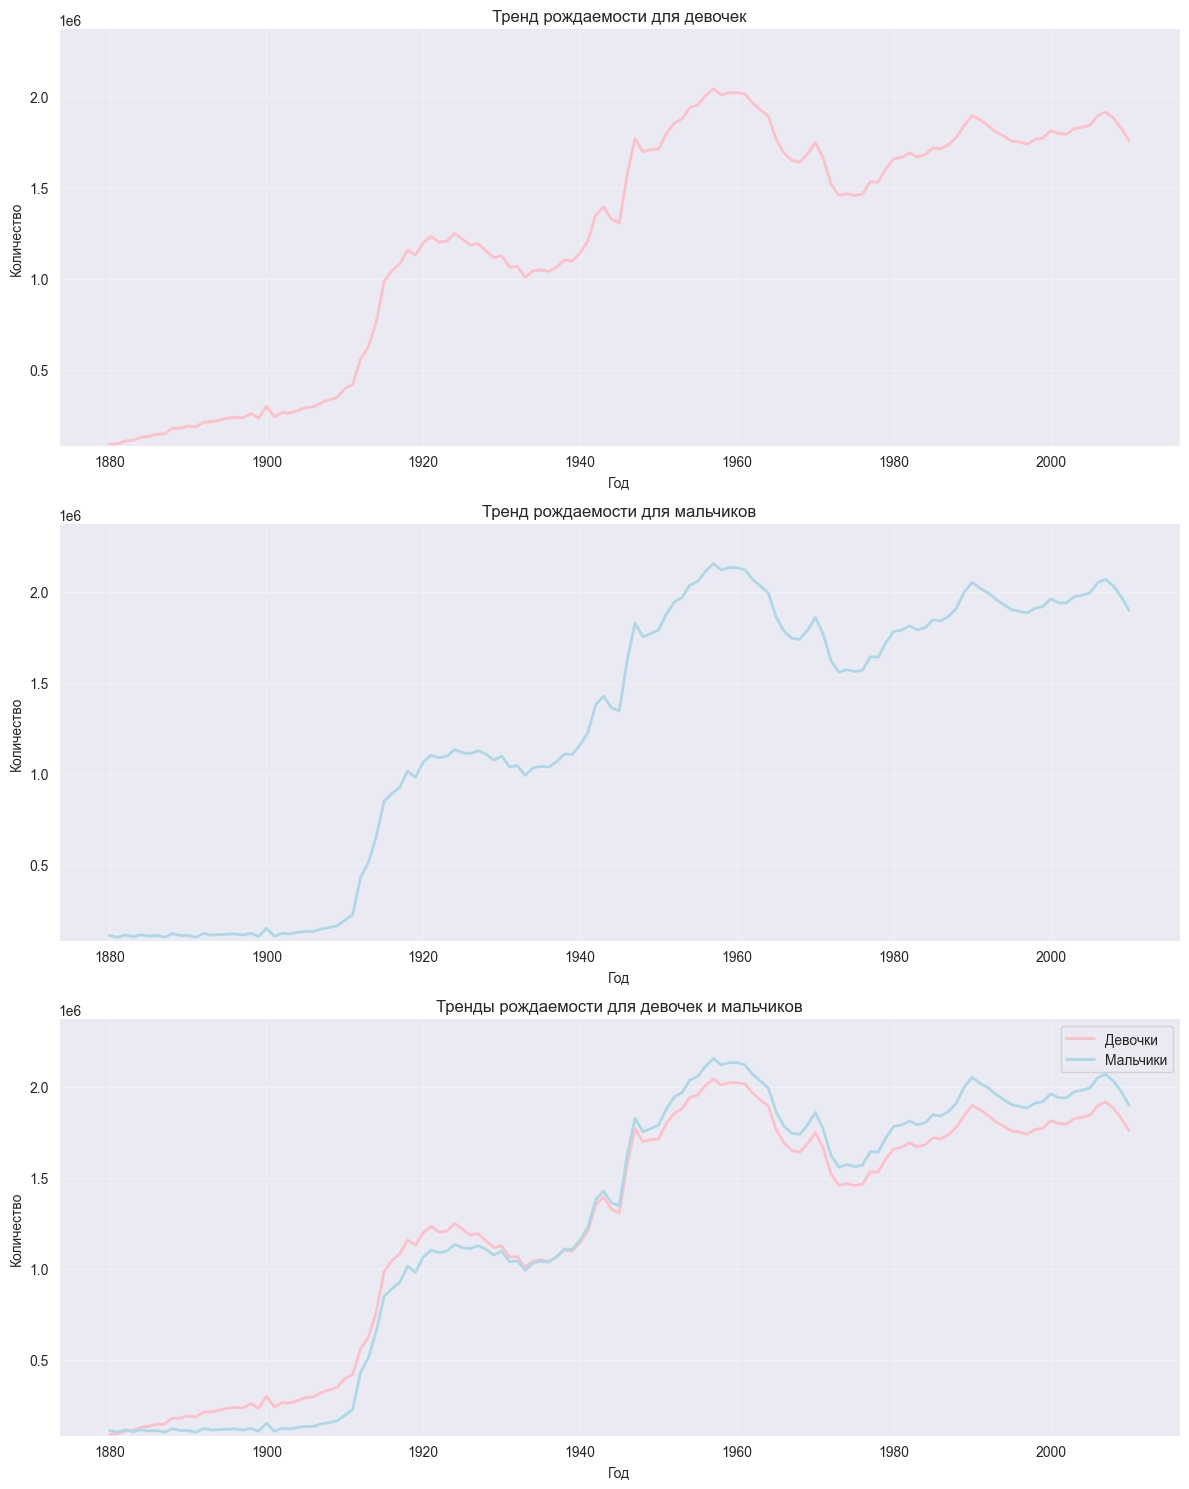

In [36]:
baby_girls = babies[babies['sex'] == 'F'].groupby('year')['number'].sum()
baby_boys = babies[babies['sex'] == 'M'].groupby('year')['number'].sum()

fig, axes = plt.subplots(3, 1, figsize=(12, 15))

axes[0].plot(baby_girls.index, baby_girls.values, color='pink', linewidth=2)
axes[0].set_title('Тренд рождаемости для девочек')
axes[0].set_xlabel('Год')
axes[0].set_ylabel('Количество')
axes[0].grid(True, alpha=0.3)

axes[1].plot(baby_boys.index, baby_boys.values, color='lightblue', linewidth=2)
axes[1].set_title('Тренд рождаемости для мальчиков')
axes[1].set_xlabel('Год')
axes[1].set_ylabel('Количество')
axes[1].grid(True, alpha=0.3)

axes[2].plot(baby_girls.index, baby_girls.values, color='pink', linewidth=2, label='Девочки')
axes[2].plot(baby_boys.index, baby_boys.values, color='lightblue', linewidth=2, label='Мальчики')
axes[2].set_title('Тренды рождаемости для девочек и мальчиков')
axes[2].set_xlabel('Год')
axes[2].set_ylabel('Количество')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

min_count = min(baby_girls.min(), baby_boys.min())
max_count = max(baby_girls.max(), baby_boys.max())

for ax in axes:
    ax.set_ylim(min_count * 0.9, max_count * 1.1)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Задание 3

1. Сгруппируйте нужным способом датафрейм babies и найдите 4 самых популярных имени за всю историю (2 женских и 2 мужских).

2. Для каждого найденного имени создайте новый датафрейм вида babies_alisa и сохраните в него данные, сколько детей с таким именем рождалось каждый год.

3. Создайте фигуру matplotlib с 4 горизонтальными графиками один под другим.

4. Постройте 4 линейных графика - тренд для каждого имени за все время.

5. Каждый график должен содержать легенду, один общий заголовок, шкалы графиков должны быть подписаны.

6. Для шкалы количество должны быть установлены лимиты, чтобы она была одинакова на обоих графиках.

7. Опишите тренды в ячейке markdown под графиками.

Самые популярные женские имена:
name
Mary        4103935
Patricia    1568742
Name: number, dtype: int64

Самые популярные мужские имена:
name
James    5049727
John     5040319
Name: number, dtype: int64


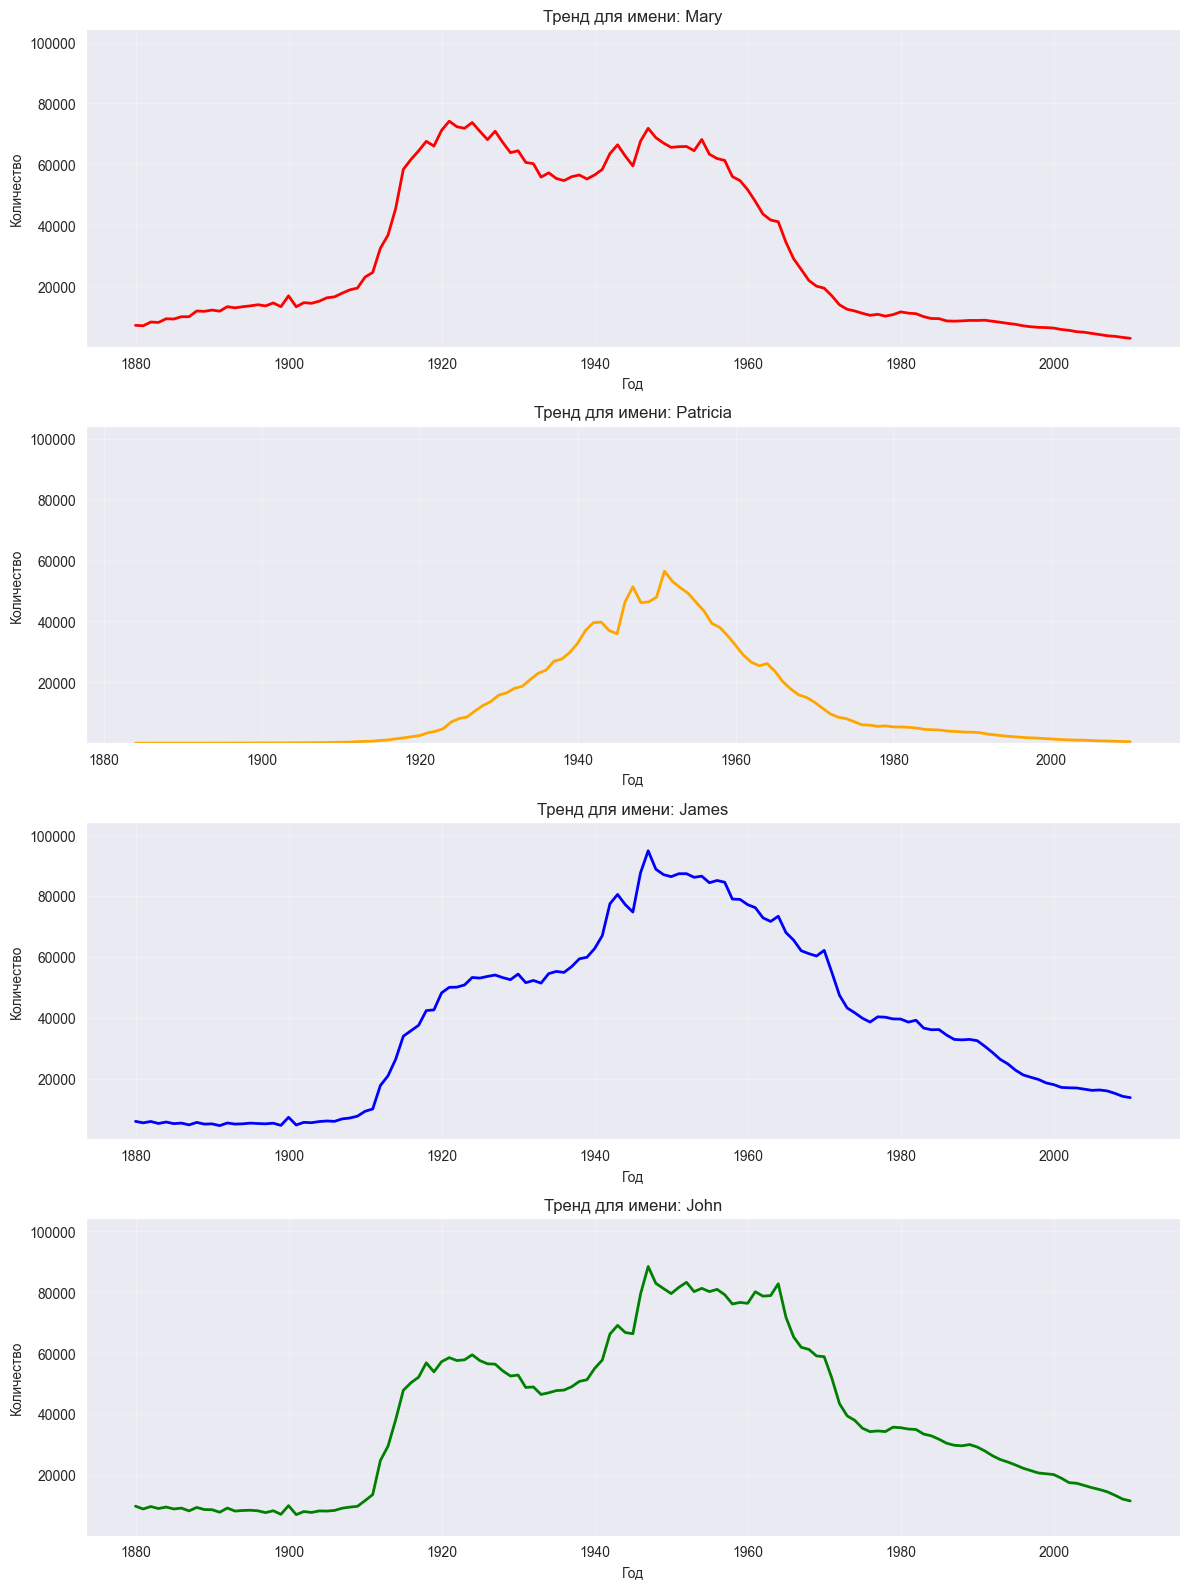

In [37]:
girl_names = babies[babies['sex'] == 'F']
boy_names = babies[babies['sex'] == 'M']
top_girl_names = girl_names.groupby('name')['number'].sum().nlargest(2)
top_boy_names = boy_names.groupby('name')['number'].sum().nlargest(2)

print("Самые популярные женские имена:")
print(top_girl_names)
print("\nСамые популярные мужские имена:")
print(top_boy_names)

girl_name1 = top_girl_names.index[0]  
girl_name2 = top_girl_names.index[1]  
boy_name1 = top_boy_names.index[0]    
boy_name2 = top_boy_names.index[1]    

name1_data = babies[babies['name'] == girl_name1].groupby('year')['number'].sum()
name2_data = babies[babies['name'] == girl_name2].groupby('year')['number'].sum()
name3_data = babies[babies['name'] == boy_name1].groupby('year')['number'].sum()
name4_data = babies[babies['name'] == boy_name2].groupby('year')['number'].sum()

fig, axes = plt.subplots(4, 1, figsize=(12, 16))

axes[0].plot(name1_data.index, name1_data.values, color='red', linewidth=2)
axes[0].set_title(f'Тренд для имени: {girl_name1}')
axes[0].set_xlabel('Год')
axes[0].set_ylabel('Количество')
axes[0].grid(True, alpha=0.3)

axes[1].plot(name2_data.index, name2_data.values, color='orange', linewidth=2)
axes[1].set_title(f'Тренд для имени: {girl_name2}')
axes[1].set_xlabel('Год')
axes[1].set_ylabel('Количество')
axes[1].grid(True, alpha=0.3)

axes[2].plot(name3_data.index, name3_data.values, color='blue', linewidth=2)
axes[2].set_title(f'Тренд для имени: {boy_name1}')
axes[2].set_xlabel('Год')
axes[2].set_ylabel('Количество')
axes[2].grid(True, alpha=0.3)

axes[3].plot(name4_data.index, name4_data.values, color='green', linewidth=2)
axes[3].set_title(f'Тренд для имени: {boy_name2}')
axes[3].set_xlabel('Год')
axes[3].set_ylabel('Количество')
axes[3].grid(True, alpha=0.3)

all_data = [name1_data, name2_data, name3_data, name4_data]
min_val = min([data.min() for data in all_data if len(data) > 0])
max_val = max([data.max() for data in all_data if len(data) > 0])

for ax in axes:
    ax.set_ylim(min_val * 0.9, max_val * 1.1)

plt.tight_layout()
plt.show()

## Часть III

Каждое задание в этой части оценивается в 0,2 балла. Всего за выполнение этой части можно получить 4 балла.

Вам предлагается проанализировать датасет с Data - вакансиями.  
Скачайте его https://disk.yandex.ru/d/QUa3pCKVk48cAQ и считайте с помощью `pd.read_csv`.




In [3]:
df = pd.read_csv('vacancies.csv')

1. Выведите первые 5 и последние 5 строк датасета. Примените к датасету методы `info` и `describe`. Сколько в датасете строк и столбцов?

In [39]:
print("Первые 5 строк:")
print(df.head())
print("\n" + "="*50 + "\n")

print("Последние 5 строк:")
print(df.tail())
print("\n" + "="*50 + "\n")

print("Информация о датасете (info):")
print(df.info())
print("\n" + "="*50 + "\n")

print("Основные статистики (describe):")
print(df.describe())
print("\n" + "="*50 + "\n")

rows = df.shape[0]
cols = df.shape[1]
print(f"В датасете {rows} строк и {cols} столбцов")

Первые 5 строк:
   Unnamed: 0                                      position_name  \
0           0                               Data Scientist Авито   
1           1                                       Data analyst   
2           2                         Data Engineer/Data Analyst   
3           3                      Стажер в направление Big Data   
4           4  Data Marketing Manager / Маркетолог по анализу...   

                                     employer_name     area  \
0                                     Changellenge   Москва   
1  Публичная Компания «Freedom Finance Global PLC»   Алматы   
2                                         IMANTECH  Ташкент   
3                                               T2   Москва   
4                                 Procter & Gamble   Алматы   

           experience       schedule        employment  \
0  От 1 года до 3 лет    Полный день  Полная занятость   
1  От 1 года до 3 лет    Полный день  Полная занятость   
2           Нет опыта 

2. Есть ли в датасете пропуски?

In [40]:
missing_values = df.isnull().sum()
print("Пропуски в датасете:")
print(missing_values[missing_values > 0])  
print(f"\nВсего пропусков: {missing_values.sum()}")

Пропуски в датасете:
salary    1307
dtype: int64

Всего пропусков: 1307


3. Есть в датасете полные дубли? Если да, удалите их (метод drop_duplicates).

In [41]:
duplicates = df.duplicated().sum()
print(f"Количество полных дубликатов: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Дубликаты удалены. Осталось строк: {df.shape[0]}")
else:
    print("Дубликатов нет")

Количество полных дубликатов: 0
Дубликатов нет


4. Сколько уникальных значений у переменной professional_roles?

In [42]:
unique_roles = df['professional_roles'].nunique()
print(f"Уникальных значений в professional_roles: {unique_roles}")

print("\nПервые 10 уникальных professional_roles:")
print(df['professional_roles'].unique()[:10])

Уникальных значений в professional_roles: 36

Первые 10 уникальных professional_roles:
['Другое' 'BI-аналитик, аналитик данных' 'Дата-сайентист' 'Аналитик'
 'Программист, разработчик' 'Директор по маркетингу и PR (CMO)'
 'Специалист технической поддержки' 'Системный аналитик'
 'Продуктовый аналитик'
 'Менеджер по продажам, менеджер по работе с клиентами']


5. Сколько в датасете вакансий, не требующих опыта?

In [43]:
print("Уникальные значения опыта:")
print(df['experience'].unique())

no_experience = df[df['experience'].str.contains('Нет опыта|нет опыта|без опыта', case=False, na=False)]
count_no_exp = len(no_experience)
print(f"\nВакансий, не требующих опыта: {count_no_exp}")

Уникальные значения опыта:
['От 1 года до 3 лет' 'Нет опыта' 'От 3 до 6 лет' 'Более 6 лет']

Вакансий, не требующих опыта: 136


6. Какое среднее количество навыков в вакансии? (переменная key_skills)

In [44]:
def count_skills(skills_str):
    if pd.isna(skills_str):  
        return 0
    elif skills_str == '[]':  
        return 0
    else:
        return len(str(skills_str).split(','))

df['skills_count'] = df['key_skills'].apply(count_skills)

mean_skills = df['skills_count'].mean()
print(f"Среднее количество навыков в вакансии: {mean_skills:.2f}")

Среднее количество навыков в вакансии: 3.88


7. Какие валюты (ключ currency в поле salary) используются для заработной платы? Создайте столбец currency.  
*Подсказка. Как вариант, можете воспользоваться функцией eval, которая исполняет код, написанный в строке. Для проверки на NaN можете использовать pd.isnull()*

In [45]:
def get_currency(salary_str):
    try:
        import ast
        salary_dict = ast.literal_eval(salary_str)
        return salary_dict.get('currency', None)
    except:
        return None

df['currency'] = df['salary'].apply(get_currency)

currencies = df['currency'].value_counts()
print("Валюты и их количество:")
print(currencies)

Валюты и их количество:
currency
RUR    181
USD     18
KZT     14
EUR      4
UZS      2
BYR      1
Name: count, dtype: int64


8. Какая компания лидирует по количеству вакансий?

In [6]:
vacancies_by_company = df['employer_name'].value_counts()
top_company = vacancies_by_company.index[0]
top_count = vacancies_by_company.iloc[0]
print(f"Компания '{top_company}' лидирует с {top_count} вакансиями")
print("\nТоп-5 компаний по количеству вакансий:")
print(vacancies_by_company.head())
print("="*50)

Компания 'СБЕР' лидирует с 146 вакансиями

Топ-5 компаний по количеству вакансий:
employer_name
СБЕР               146
Aston               70
Т-Банк              56
EPAM Uzbekistan     46
Газпромбанк         30
Name: count, dtype: int64


9.  Какая компания лидирует по количеству вакансий с указанием заработной платы?

In [8]:
df_with_salary = df[df['salary'].notna()]
vacancies_with_salary = df_with_salary['employer_name'].value_counts()
top_company_salary = vacancies_with_salary.index[0]
top_count_salary = vacancies_with_salary.iloc[0]
print(f"Компания '{top_company_salary}' лидирует с {top_count_salary} вакансиями с указанием зарплаты")

Компания 'Aston' лидирует с 29 вакансиями с указанием зарплаты


10. Создайте столбец salary_num. Рассчитайте его, используя столбец salary. Если в это столбце указана вилка зарплаты, используйте среднее значение между from и to. Если указано только одно из значений (from или to, используйте его) **(2)**

In [ ]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

11. Какая средняя заработная плата среди вакансий в рублях? А медианная заработная плата?  

In [ ]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

12. Создайте столбец is_python_requirement, который принимает значение 1, если в key_skills присутствует python (учитывайте написание в любом регистре, а также вхождения подстроки python.).  Какой процент вакансий требует знания python?

In [10]:
df['is_python_requirement'] = df['key_skills'].apply(
    lambda x: 1 if pd.notna(x) and 'python' in str(x).lower() else 0
)

# Считаем процент
total_vacancies = len(df)
python_vacancies = df['is_python_requirement'].sum()
percentage = (python_vacancies / total_vacancies) * 100

print(f"Всего вакансий: {total_vacancies}")
print(f"Вакансий с требованием Python: {python_vacancies}")
print(f"Процент вакансий с требованием Python: {percentage:.2f}%")

Всего вакансий: 1527
Вакансий с требованием Python: 633
Процент вакансий с требованием Python: 41.45%


13. Сгруппируйте по столбцам experience, schedule, employment, is_python_requirement (сразу по четырем столбцам). Найдите по каждой группе:
- количество опубликованных вакансий
- количество компаний, которые опубликовали вакансии
- среднюю заработную плату среди вакансий с указанием зарплаты в рублях


In [11]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

14. Создайте столбец count_skills. В нём должна быть длина списка, который находит в столбце key_skills. Обратите внимание, что изначально столбец key_skills - строка, например, '[]' Подумайте, как превратить её в список и посчитать его длину.  

In [ ]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

15. Создайте столбец len_descr, в котором должна быть длина описания (description) в символах без учета html тегов ("<...>"). Напишите для этого функцию get_len_descr.  Можете использовать регулярные выражения.
То есть, ваш код может выглядеть, например, так:

In [13]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

16. Постройте таблицу корреляций с тремя переменными: salary_num, len_descr, count_skills.  

In [15]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

17. Постройте тепловую карту из таблицы из предыдущего пункта.

In [17]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

18. Какие скиллы чаще всего требуются? Выведите топ-10 требуемых скиллов.

In [52]:
def extract_skills(skills_str):
    if pd.isna(skills_str):
        return []
    try:
        import ast
        skills_list = ast.literal_eval(str(skills_str))
        if isinstance(skills_list, list):
            return [skill.strip().lower() for skill in skills_list]
        else:
            return []
    except:
        return []

all_skills = []
for skills in df['key_skills']:
    all_skills.extend(extract_skills(skills))

from collections import Counter
skills_counter = Counter(all_skills)

top_10_skills = skills_counter.most_common(10)

print("Топ-10 требуемых навыков:")
for i, (skill, count) in enumerate(top_10_skills, 1):
    print(f"{i}. {skill}: {count} раз")

Топ-10 требуемых навыков:
1. python: 633 раз
2. sql: 574 раз
3. etl: 154 раз
4. big data: 146 раз
5. hadoop: 119 раз
6. postgresql: 113 раз
7. dwh: 111 раз
8. clickhouse: 102 раз
9. английский язык: 93 раз
10. математический анализ: 90 раз


19. Постройте гистограмму распределения зарплаты среди вакансий в рублях.  

In [18]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。

20. Постройте boxplot зарплаты (среди вакансий в рублях) с группировкой по полю experience

In [20]:
# ( ͡° ͜ʖ ͡°)づ ━━ ✫・*。